# Balanced Impact Analysis of Men's T20I Batting Performances


Outline:
- Data loading & cleaning
- Feature engineering
- Aggregating player statistics
- Computing the Balanced Impact Score
- Applying K means Clustering 




In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (10,6)})

In [2]:
def load_data(path):
    print("Loading data...")
    return pd.read_csv(path)

def clean_and_engineer(df):
    print("Cleaning & engineering features...")
    df['Innings Date'] = pd.to_datetime(df['Innings Date'], errors='coerce')
    df['Innings Runs Scored Num'] = pd.to_numeric(df['Innings Runs Scored Num'], errors='coerce')
    df['Innings Balls Faced'] = pd.to_numeric(df['Innings Balls Faced'], errors='coerce')
    df['Innings Boundary Fours'] = pd.to_numeric(df['Innings Boundary Fours'], errors='coerce')
    df['Innings Boundary Sixes'] = pd.to_numeric(df['Innings Boundary Sixes'], errors='coerce')
    return df

def aggregate_players(df):
    print("Aggregating players...")
    valid_df = df[(df['Innings Balls Faced'] > 0) & (~df['Innings Runs Scored Num'].isna())]

    agg_dict = {
        'Matches': ('Innings Number', 'count'),
        'TotalRuns': ('Innings Runs Scored Num', 'sum'),
        'TotalBalls': ('Innings Balls Faced', 'sum'),
        'Outs': ('Innings Not Out Flag', lambda x: (x == 0).sum()),
        'Fours': ('Innings Boundary Fours', 'sum'),
        'Sixes': ('Innings Boundary Sixes', 'sum'),
    }

    #Milestone Columns
    if '50s' in df.columns:
        agg_dict['Fifties'] = ('50s', 'sum')
    elif "'50's" in df.columns:
        agg_dict['Fifties'] = ("'50's", 'sum')

    if '100s' in df.columns:
        agg_dict['Hundreds'] = ('100s', 'sum')
    elif "'100's" in df.columns:
        agg_dict['Hundreds'] = ("'100's", 'sum')

    grouped = valid_df.groupby('Innings Player').agg(**agg_dict).reset_index()

    grouped['Average'] = grouped['TotalRuns'] / grouped['Outs']
    grouped['StrikeRate'] = (grouped['TotalRuns'] / grouped['TotalBalls']) * 100
    grouped['BoundaryRuns'] = grouped['Fours']*4 + grouped['Sixes']*6
    grouped['Boundary%'] = grouped['BoundaryRuns'] / grouped['TotalRuns'] * 100
    return grouped


def compute_impact(df, min_balls=500, min_inns=20):
    print("Computing impact scores...")
    eligible = df[(df['TotalBalls'] >= min_balls) & (df['Matches'] >= min_inns)].copy()
    eligible['Avg_z'] = (eligible['Average'] - eligible['Average'].mean()) / eligible['Average'].std()
    eligible['SR_z'] = (eligible['StrikeRate'] - eligible['StrikeRate'].mean()) / eligible['StrikeRate'].std()
    eligible['ImpactScore'] = (eligible['Avg_z'] + eligible['SR_z']) / 2
    return eligible.sort_values('ImpactScore', ascending=False)

In [3]:
csv_path = "Men T20I Player Innings Stats - 21st Century.csv"

#Pipeline
df = load_data(csv_path)
df = clean_and_engineer(df)
player_df = aggregate_players(df)
impact_df = compute_impact(player_df)

print("=== Player Summary (first 10 rows) ===")
display(player_df.head(10))

Loading data...
Cleaning & engineering features...


C:\Users\hkssf\AppData\Local\Temp\ipykernel_4764\4138015100.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Innings Date'] = pd.to_datetime(df['Innings Date'], errors='coerce')


Aggregating players...
Computing impact scores...
=== Player Summary (first 10 rows) ===


,Innings Player,Matches,TotalRuns,TotalBalls,Outs,Fours,Sixes,Average,StrikeRate,BoundaryRuns,Boundary%
0,A Balbirnie,114,2751.0,2115.0,108,323.0,38.0,25.472222,130.070922,1520.0,55.252635
1,A Dananjaya,33,147.0,171.0,24,18.0,0.0,6.125000,85.964912,72.0,48.979592
2,A Flintoff,21,228.0,180.0,18,21.0,6.0,12.666667,126.666667,120.0,52.631579
3,A Khan,3,6.0,12.0,3,0.0,0.0,2.000000,50.000000,0.0,0.000000
4,A Ndlovu,3,6.0,12.0,3,0.0,0.0,2.000000,50.000000,0.0,0.000000
5,A Nehra,15,84.0,117.0,15,3.0,6.0,5.600000,71.794872,48.0,57.142857
6,A Nel,3,0.0,6.0,0,0.0,0.0,NaN,0.000000,0.0,NaN
7,A Nortje,2,4.0,12.0,2,0.0,0.0,2.000000,33.333333,0.0,0.000000
8,A Shahzad,3,0.0,9.0,0,0.0,0.0,NaN,0.000000,0.0,NaN
9,A Symonds,33,1011.0,597.0,21,99.0,30.0,48.142857,169.346734,576.0,56.973294


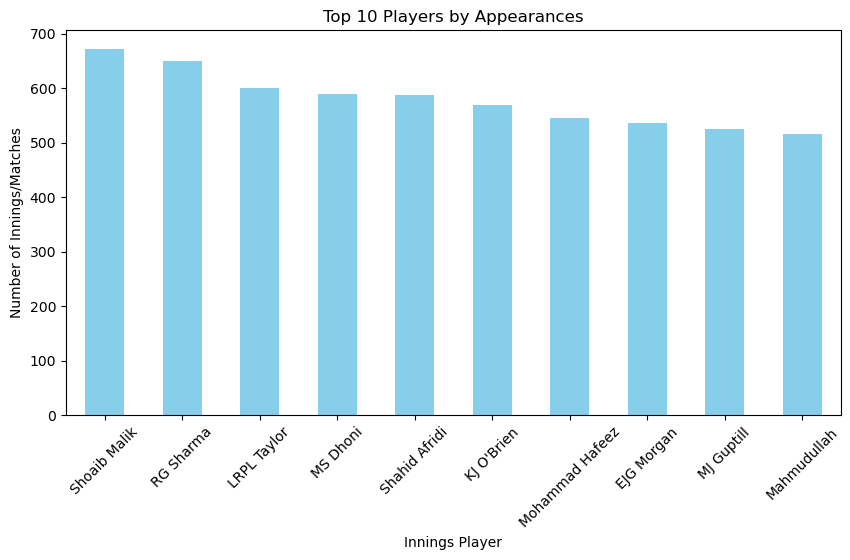

In [4]:
player_col = None
for col in df.columns:
    if "player" in col.lower():
        player_col = col
        break

if player_col:
    #Top 10 players by count of appearances
    top_players = df[player_col].value_counts().nlargest(10)
    plt.figure(figsize=(10,5))
    top_players.plot(kind='bar', color='skyblue')
    plt.title("Top 10 Players by Appearances")
    plt.ylabel("Number of Innings/Matches")
    plt.xticks(rotation=45)
    plt.show()

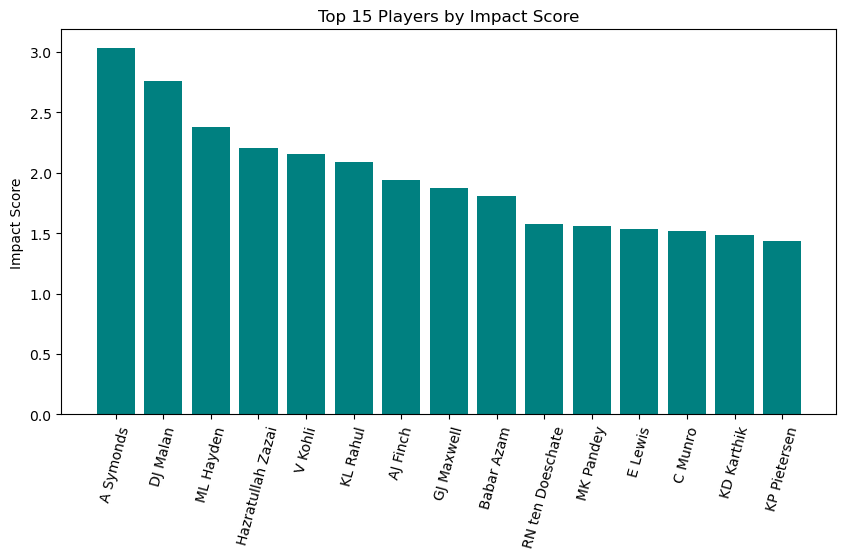

In [5]:
#Top 15 players by Impact Score
top_impact = impact_df.nlargest(15, 'ImpactScore')
plt.figure(figsize=(10,5))
plt.bar(top_impact['Innings Player'], top_impact['ImpactScore'], color='teal')
plt.title("Top 15 Players by Impact Score")
plt.ylabel("Impact Score")
plt.xticks(rotation=75)
plt.show()

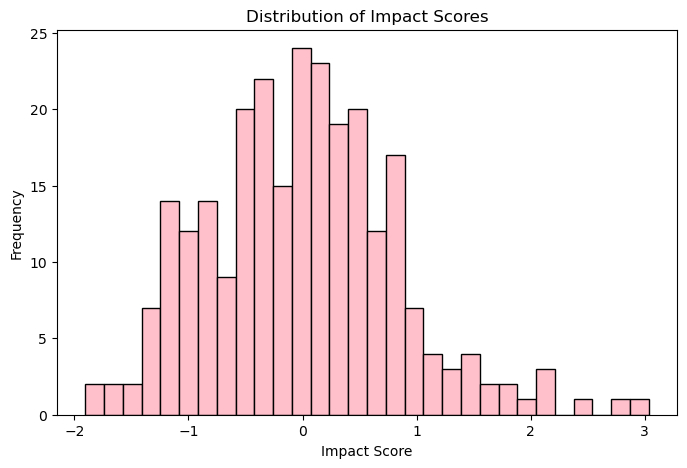

In [6]:
#Distribution of Impact Scores
plt.figure(figsize=(8,5))
plt.hist(impact_df['ImpactScore'], bins=30, color='pink', edgecolor='black')
plt.title("Distribution of Impact Scores")
plt.xlabel("Impact Score")
plt.ylabel("Frequency")
plt.show()

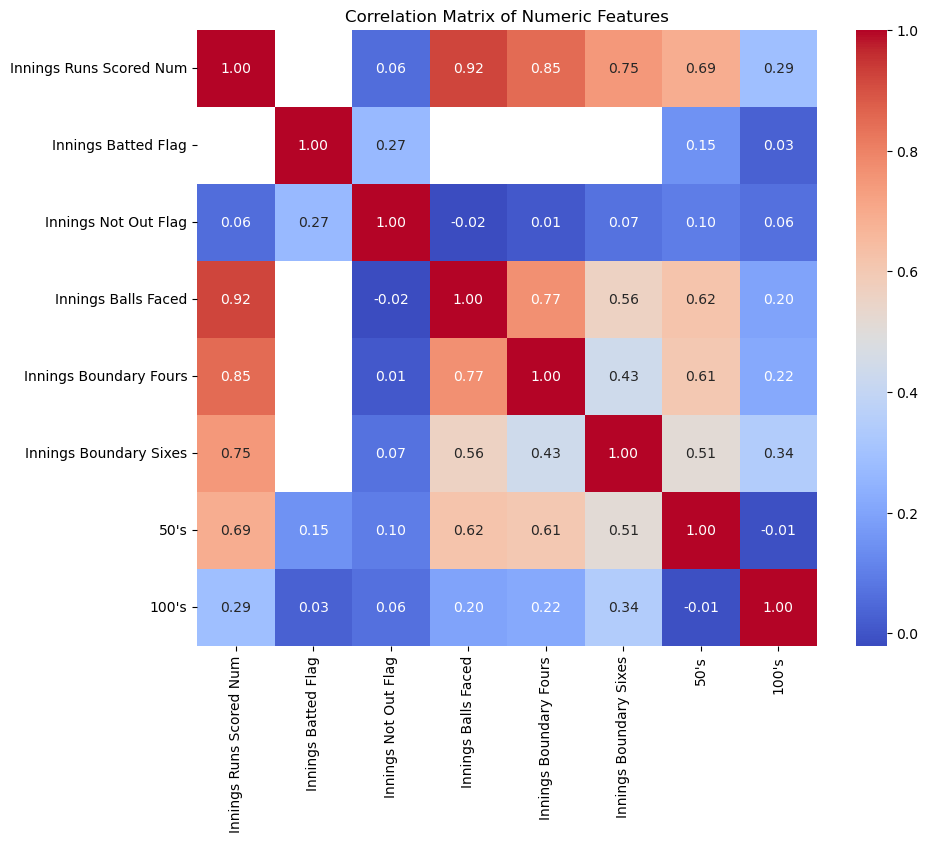

In [7]:
#Selecting numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty:
    corr = numeric_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Numeric Features")
    plt.show()
else:
    print("No numeric columns available for correlation plot.")

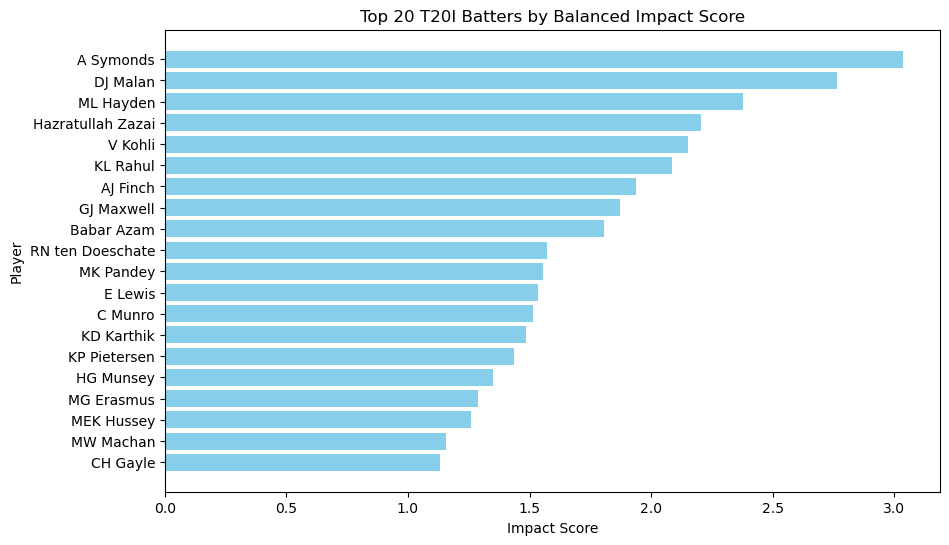

In [8]:
#Top 20 impact score chart
top20 = impact_df.head(20)
plt.figure(figsize=(10,6))
plt.barh(top20['Innings Player'], top20['ImpactScore'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Impact Score")
plt.ylabel("Player")
plt.title("Top 20 T20I Batters by Balanced Impact Score")
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

features = ['Average', 'StrikeRate', 'Boundary%', 'ImpactScore']
cluster_df = impact_df.copy()

cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan).dropna(subset=features)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df[features])

#Applying K Means
k = 3  
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(scaled_features)

#Principal Component Analysis
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_features)
cluster_df['PC1'] = pca_coords[:, 0]
cluster_df['PC2'] = pca_coords[:, 1]

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


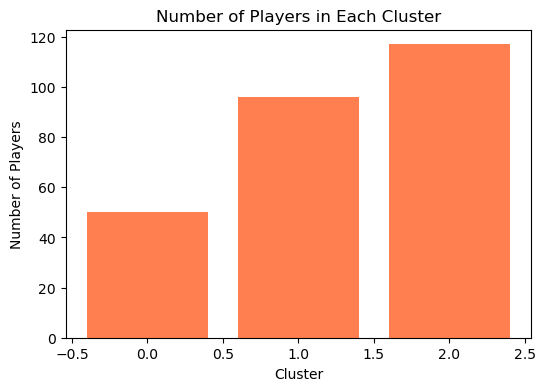

In [10]:
#Cluster sizes
plt.figure(figsize=(6,4))
cluster_counts = cluster_df['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color='coral')
plt.title("Number of Players in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Players")
plt.show()

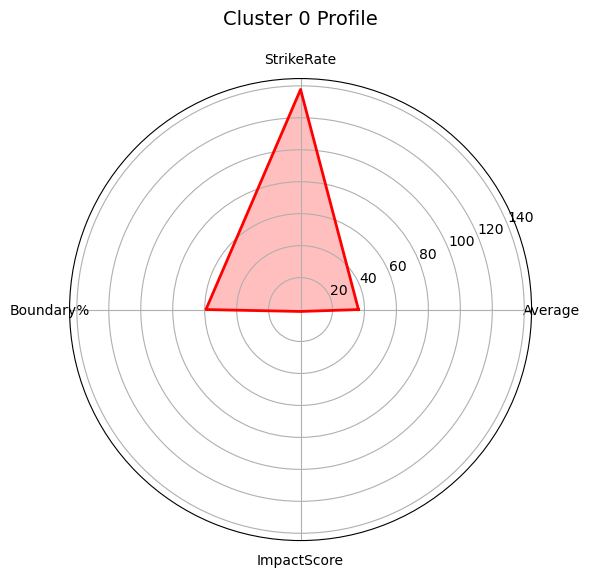

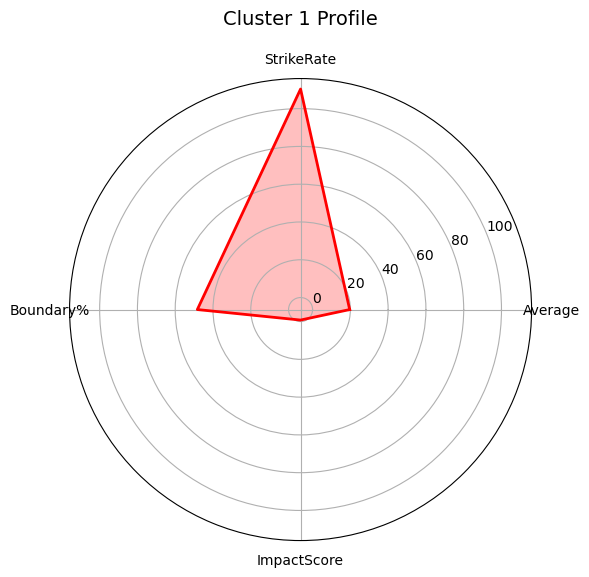

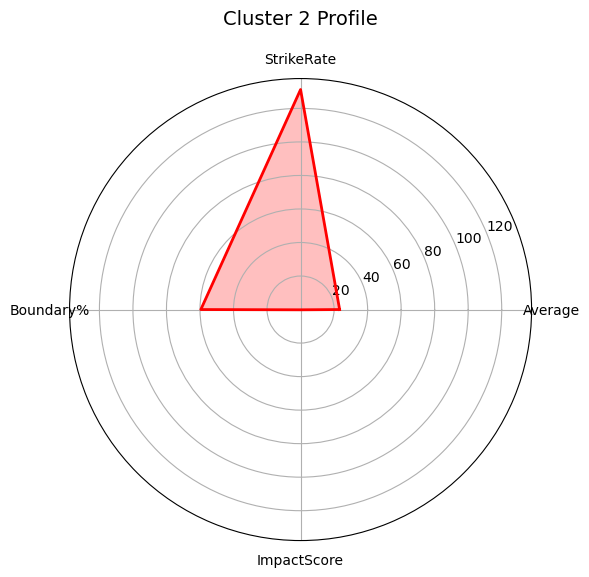

In [11]:
#Radar chart
def make_radar_chart(data, title, categories):
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    data = list(data) + [data[0]]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, data, color='red', linewidth=2)
    ax.fill(angles, data, color='red', alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    plt.title(title, size=14, y=1.1)
    plt.show()

features = ['Average', 'StrikeRate', 'Boundary%', 'ImpactScore']
features = [f for f in features if f in cluster_df.columns]
cluster_profiles = cluster_df.groupby('Cluster')[features].mean()

for cluster_id, row in cluster_profiles.iterrows():
    make_radar_chart(row.values.tolist(), f"Cluster {cluster_id} Profile", features)

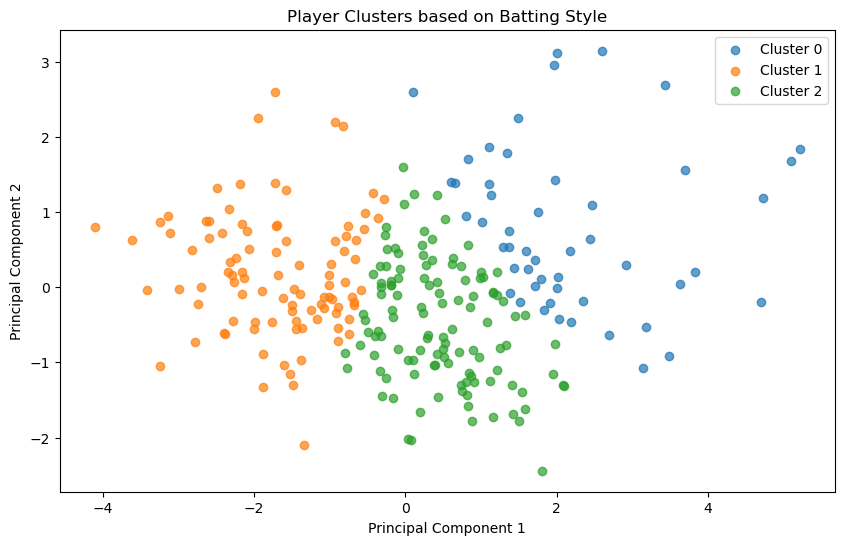

In [12]:
#Cluster Plot
plt.figure(figsize=(10, 6))
for cluster in range(k):
    subset = cluster_df[cluster_df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.7)
plt.title('Player Clusters based on Batting Style')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [13]:
cluster_profiles = cluster_df.groupby('Cluster')[features].mean()
print("\n========== Cluster Profiles (Average Feature Values) ===========")
display(cluster_profiles)


========== Cluster Profiles (Average Feature Values) ===========


,Average,StrikeRate,Boundary%,ImpactScore
Cluster,,,,
0,36.229429,137.737498,59.234382,1.196872
1,19.647161,110.371803,48.290617,-0.798844
2,23.297231,131.257034,59.510781,0.143978


In [14]:
#Top Players per Cluster
print("\n========= Top 5 Players in Each Cluster (by Impact Score) =========")
for cluster in range(k):
    print(f"\nCluster {cluster}:")
    top_players = cluster_df[cluster_df['Cluster'] == cluster].sort_values('ImpactScore', ascending=False).head(5)
    display(top_players[['Innings Player', 'ImpactScore', 'Average', 'StrikeRate', 'Boundary%']])


========= Top 5 Players in Each Cluster (by Impact Score) =========

Cluster 0:


,Innings Player,ImpactScore,Average,StrikeRate,Boundary%
9,A Symonds,3.035513,48.142857,169.346734,56.973294
209,DJ Malan,2.763478,52.111111,153.770492,66.524520
544,ML Hayden,2.379790,51.333333,143.925234,73.376623
335,Hazratullah Zazai,2.206155,41.475000,157.549858,77.034358
935,V Kohli,2.153084,50.800000,138.248392,53.256979



Cluster 1:


,Innings Player,ImpactScore,Average,StrikeRate,Boundary%
336,Hussain Talat,0.102504,28.538462,120.064725,45.822102
749,RS Bopara,0.049847,28.440000,118.697830,44.725738
52,AN Kervezee,0.002060,32.111111,110.305344,38.754325
152,CG Williams,-0.004267,27.666667,118.571429,48.192771
541,MJG Rippon,-0.004386,30.857143,112.500000,36.111111



Cluster 2:


,Innings Player,ImpactScore,Average,StrikeRate,Boundary%
294,GJ Delany,0.935335,24.607843,152.121212,62.310757
606,N Davin,0.889444,22.333333,155.092593,66.268657
484,LE Bosman,0.793733,24.846154,147.488584,70.588235
394,JJ Roy,0.776852,24.571429,147.512864,68.139535
403,JM Bairstow,0.716256,27.884615,139.423077,63.172414


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

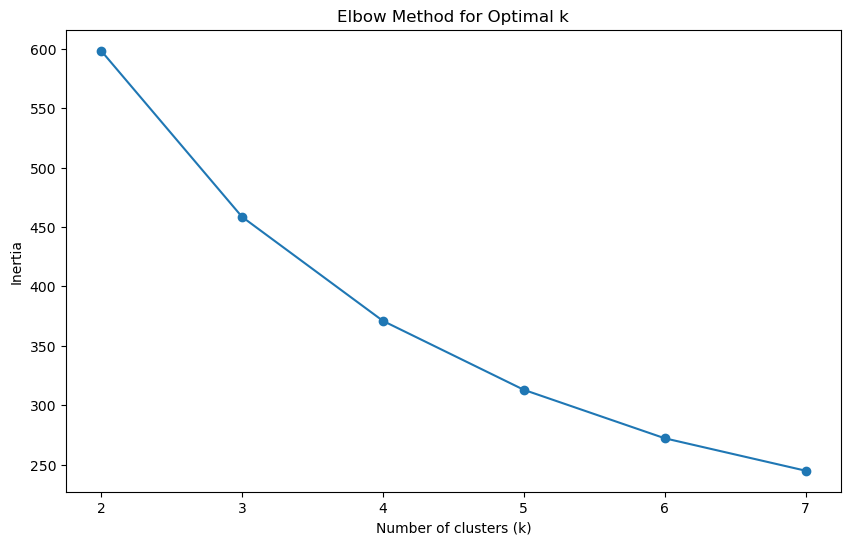

In [15]:
from sklearn.metrics import silhouette_score

inertia_values = []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia_values.append(km.inertia_)

plt.plot(K, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [16]:
score = silhouette_score(scaled_features, cluster_df['Cluster'])
print(f"Silhouette Score for k={k}: {score:.3f}")

Silhouette Score for k=7: 0.297


In [17]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}
for test_k in range(2, 11):
    km = KMeans(n_clusters=test_k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores[test_k] = score

print("======== Silhouette Scores for k values =======")
for k_val, score_val in silhouette_scores.items():
    print(f"k={k_val}: {score_val:.3f}")

#Finding best k
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_k]
print(f"\nOptimal k based on silhouette score: {best_k} (Score = {best_score:.3f})")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

======== Silhouette Scores for k values =======
k=2: 0.360
k=3: 0.297
k=4: 0.277
k=5: 0.285
k=6: 0.277
k=7: 0.280
k=8: 0.269
k=9: 0.262
k=10: 0.250

Optimal k based on silhouette score: 2 (Score = 0.360)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


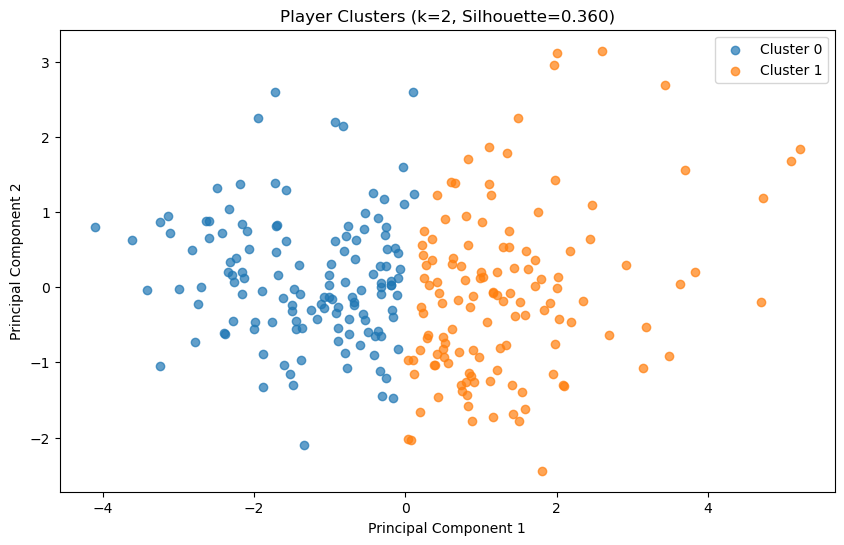

In [18]:
#Rerunning clustering with best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(scaled_features)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_features)
cluster_df['PC1'] = pca_coords[:, 0]
cluster_df['PC2'] = pca_coords[:, 1]

plt.figure(figsize=(10, 6))
for cluster in range(best_k):
    subset = cluster_df[cluster_df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.7)
plt.title(f'Player Clusters (k={best_k}, Silhouette={best_score:.3f})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()